In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-31 15:07:50.313337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774969670.505708      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774969670.566650      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774969671.047788      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774969671.047834      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774969671.047837      55 computation_placer.cc:177] computation placer alr

In [2]:
train_path = "/kaggle/input/datasets/mohammedaaquila/processed-dataset-mri/processed_dataset/train"
val_path   = "/kaggle/input/datasets/mohammedaaquila/processed-dataset-mri/processed_dataset/val"
test_path  = "/kaggle/input/datasets/mohammedaaquila/processed-dataset-mri/processed_dataset/test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 9593 images belonging to 5 classes.
Found 1199 images belonging to 5 classes.
Found 1200 images belonging to 5 classes.
Classes: {'Angiosarcoma': 0, 'Cholangiocarcinoma': 1, 'Healthy': 2, 'Hemangioma': 3, 'Hepatocellular_Carcinoma': 4}


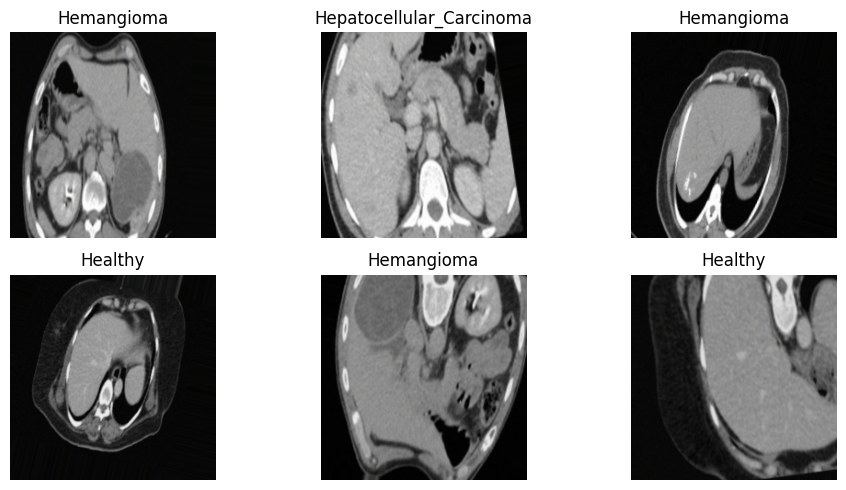

In [4]:
images, labels = next(train_generator)

# Get class names in correct order
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    
    plt.imshow(images[i])
    
    # Convert one-hot to class index
    label_index = np.argmax(labels[i])
    label_name = class_names[label_index]
    
    plt.title(label_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1774969732.970475      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
for layer in base_model.layers:
    layer.trainable = False

In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1774969856.533645     157 service.cc:152] XLA service 0x7812600026b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774969856.533688     157 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774969860.079779     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.1875 - loss: 2.3402   

I0000 00:00:1774969872.679367     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


300/300 ━━━━━━━━━━━━━━━━━━━━ 216s 624ms/step - accuracy: 0.3402 - loss: 1.6100 - val_accuracy: 0.6397 - val_loss: 0.9722
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 114s 379ms/step - accuracy: 0.5557 - loss: 1.0654 - val_accuracy: 0.7248 - val_loss: 0.7702
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 375ms/step - accuracy: 0.6153 - loss: 0.9057 - val_accuracy: 0.7698 - val_loss: 0.6410
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 115s 383ms/step - accuracy: 0.6769 - loss: 0.7824 - val_accuracy: 0.8090 - val_loss: 0.5591
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 116s 385ms/step - accuracy: 0.7022 - loss: 0.7256 - val_accuracy: 0.8349 - val_loss: 0.4988
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 115s 384ms/step - accuracy: 0.7227 - loss: 0.6490 - val_accuracy: 0.8540 - val_loss: 0.4409
Epoch 7/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 117s 391ms/step - accuracy: 0.7545 - loss: 0.6141 - val_accuracy: 0.8474 - val_loss: 0.4230
Epoch 8/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 114s 381ms/step - accuracy: 0.7694 - loss: 0.56

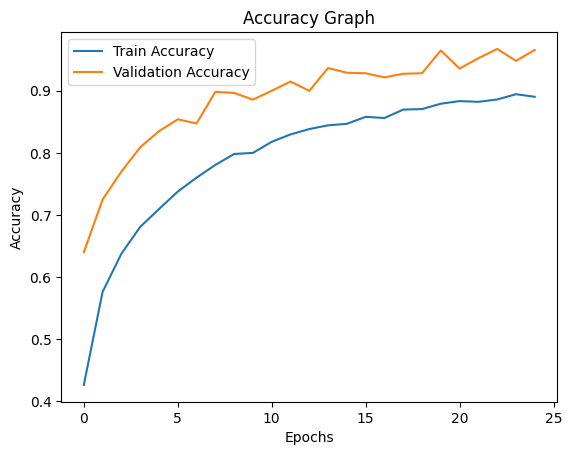

In [12]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

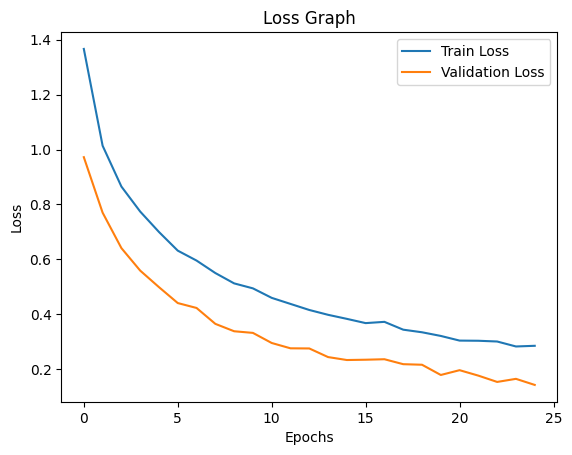

In [13]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9591 - loss: 0.1810


In [16]:
print("Train Accuracy      :", round(history.history['accuracy'][-1] * 100, 2), "%")
print("Validation Accuracy :", round(history.history['val_accuracy'][-1] * 100, 2), "%")
print("Test Accuracy       :", round(test_accuracy * 100, 2), "%")

Train Accuracy      : 89.03 %
Validation Accuracy : 96.58 %
Test Accuracy       : 96.75 %


38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 384ms/step


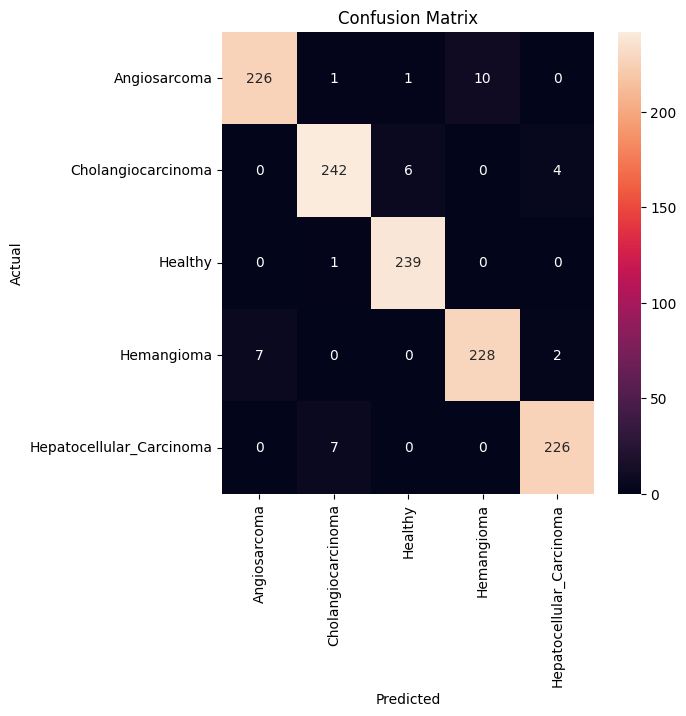

In [17]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
# Get class names in correct index order
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=class_names
))

                          precision    recall  f1-score   support

            Angiosarcoma       0.97      0.95      0.96       238
      Cholangiocarcinoma       0.96      0.96      0.96       252
                 Healthy       0.97      1.00      0.98       240
              Hemangioma       0.96      0.96      0.96       237
Hepatocellular_Carcinoma       0.97      0.97      0.97       233

                accuracy                           0.97      1200
               macro avg       0.97      0.97      0.97      1200
            weighted avg       0.97      0.97      0.97      1200



Actual Class    : Angiosarcoma
Predicted Class : Angiosarcoma
Confidence      : 76.72 %


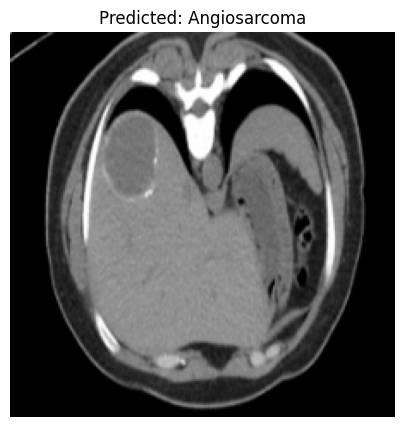

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

IMG_HEIGHT = 224
IMG_WIDTH  = 224

# Select one batch from test generator
test_images, test_labels = next(test_generator)

# Choose one image from batch
sample_index = 0
img = test_images[sample_index]
img_batch = np.expand_dims(img, axis=0)

# Predict
preds = model.predict(img_batch, verbose=0)
predicted_index = np.argmax(preds[0])
confidence = np.max(preds[0])

class_names = list(test_generator.class_indices.keys())
actual_index = np.argmax(test_labels[sample_index])

print("Actual Class    :", class_names[actual_index])
print("Predicted Class :", class_names[predicted_index])
print("Confidence      :", round(confidence * 100, 2), "%")

# Show original image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Predicted: {class_names[predicted_index]}")
plt.axis("off")
plt.show()

In [20]:
def generate_gradcam(model, img_batch, predicted_index, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch, training=False)
        class_channel = predictions[:, predicted_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

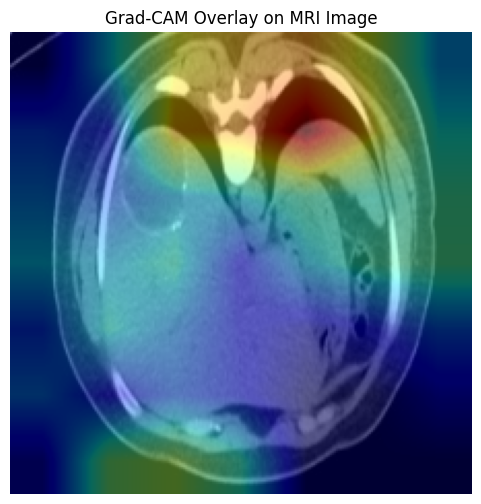

In [22]:
import matplotlib.cm as cm

# Resize heatmap to 224x224
heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))

# Convert heatmap to color
heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
heatmap_colored = np.uint8(255 * heatmap_colored)

# Convert original image to uint8
original_img = np.uint8(img * 255)

# Overlay
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay on MRI Image")
plt.axis("off")
plt.show()

In [23]:
output_path = "gradcam_result.png"

cv2.imwrite(output_path, cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR))

print("Grad-CAM overlay image saved as:", output_path)

Grad-CAM overlay image saved as: gradcam_result.png


In [25]:
# ==========================
# SAVE MODEL
# ==========================

model.save("DenseNet121_Liver_MRI_Model.keras")